## 1. IMPORT LIBRARIES

In [44]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 290.7 kB/s eta 0:00:27
   -- ------------------------------------- 0.5/8.3 MB 290.7 kB/s eta 0:00:27
   -- ------------------------------------- 0.5/8.3 MB 290.7 kB/s eta 0:00:27
   -- ------------------------------------- 0.5/8.3 MB 290.7 kB/s eta 0:00:27
   --- ------------------------------------ 0.8/8.3 MB 297.3 kB/s eta 0:00:26
   --- ------------------------------------ 0.8/8.3 MB 297


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")


## 2. IMPORT DATASET

In [2]:
cars_dataset = pd.read_csv("Cars.csv")
cars_dataset

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 3. DATA UNDERSTANDING

### 3.1 PERFORM INITIAL ANALYSIS ON THE DATA

In [3]:
cars_dataset.shape

(81, 5)

In [4]:
cars_dataset.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [5]:
cars_dataset.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [6]:
cars_dataset.describe().round(1)

,HP,MPG,VOL,SP,WT
count,81.0,81.0,81.0,81.0,81.0
mean,117.5,34.4,98.8,121.5,32.4
std,57.1,9.1,22.3,14.2,7.5
min,49.0,12.1,50.0,99.6,15.7
25%,84.0,27.9,89.0,113.8,29.6
50%,100.0,35.2,101.0,118.2,32.7
75%,140.0,39.5,113.0,126.4,37.4
max,322.0,53.7,160.0,169.6,53.0


## NOW LETS CHECK FOR ASSUMPTIONS

### TEST 1. LINEARITY TEST

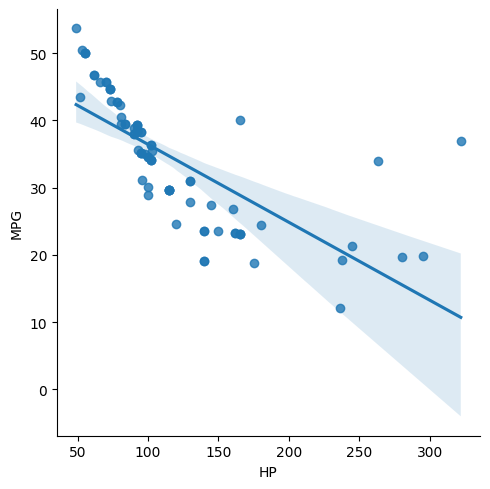

In [7]:
sns.lmplot(data = cars_dataset,x="HP",y="MPG",) ##for linearity test lmplot will be apt

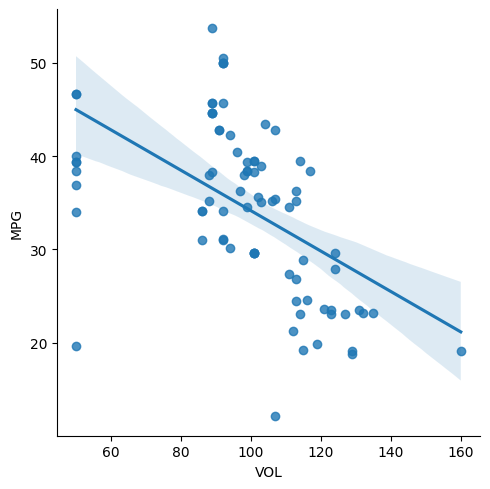

In [8]:
sns.lmplot(data=cars_dataset,x="VOL",y="MPG")

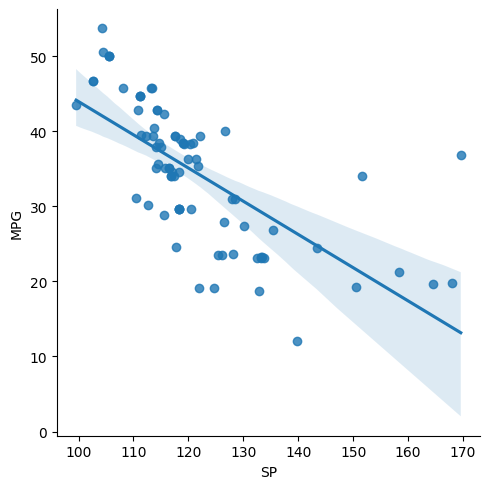

In [9]:
sns.lmplot(data=cars_dataset,x="SP",y="MPG")

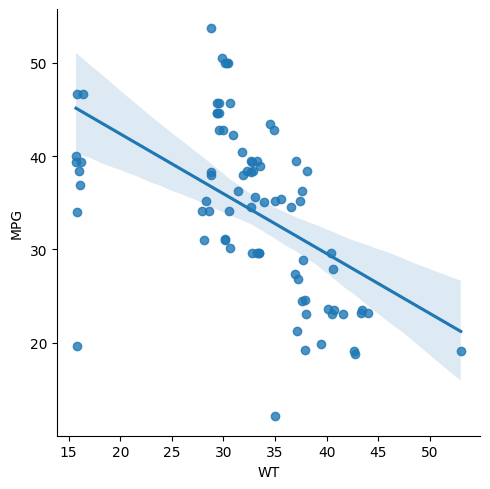

In [10]:
sns.lmplot(data=cars_dataset,x="WT",y="MPG")

#### LINEARUTY TEST FAILED: ALL DOTS SHOULD FALL ALMOST CLOSER TO THE LINE, IN ALL LMPLOTS THE POINTS ARE VERY MUCH SCATTERED

### TEST2. NORMALITY TEST

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

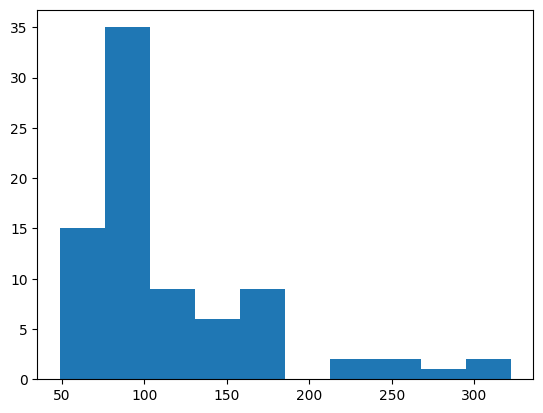

In [11]:
plt.hist(cars_dataset["HP"])

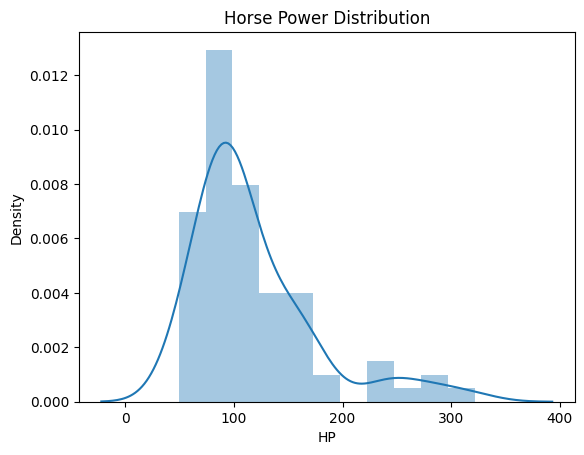

In [12]:
sns.distplot(cars_dataset["HP"])
plt.title("Horse Power Distribution")
plt.show()

(array([ 9.,  0.,  0., 22., 20., 15.,  8.,  6.,  0.,  1.]),
 array([ 50.,  61.,  72.,  83.,  94., 105., 116., 127., 138., 149., 160.]),
 <BarContainer object of 10 artists>)

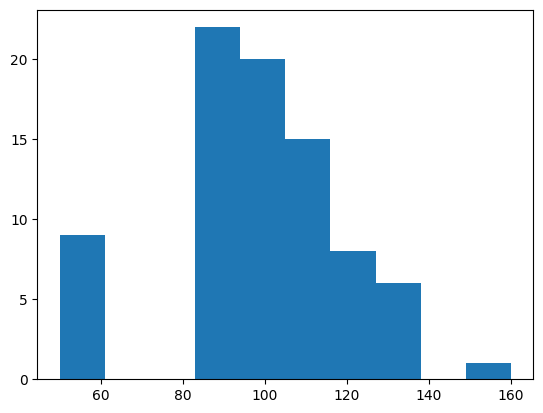

In [13]:
plt.hist(cars_dataset["VOL"])

(array([ 8., 12., 32., 10., 10.,  2.,  1.,  2.,  1.,  3.]),
 array([ 99.56490661, 106.56826723, 113.57162785, 120.57498847,
        127.57834909, 134.58170971, 141.58507032, 148.58843094,
        155.59179156, 162.59515218, 169.5985128 ]),
 <BarContainer object of 10 artists>)

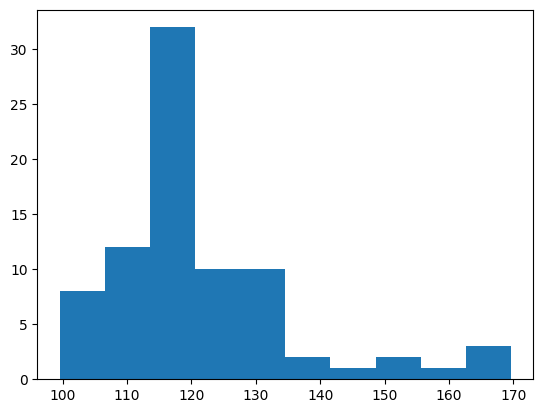

In [14]:
plt.hist(cars_dataset["SP"])

(array([ 9.,  0.,  0., 22., 19., 18.,  7.,  5.,  0.,  1.]),
 array([15.71285853, 19.44134791, 23.1698373 , 26.89832668, 30.62681606,
        34.35530544, 38.08379483, 41.81228421, 45.54077359, 49.26926298,
        52.99775236]),
 <BarContainer object of 10 artists>)

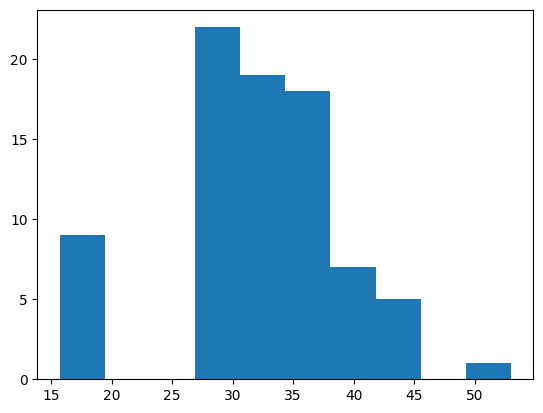

In [15]:
plt.hist(cars_dataset["WT"])

#### NORMALITY TEST ALSO FAILED

### TEST3. CORRELATION MATRIX \ MULTI COLLINEARITY TEST

In [16]:
corr_data = cars_dataset.corr() ### chk for multi collinearity, ip datas should not ne dependent on each other///// ip data should not b highly correlated
corr_data

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

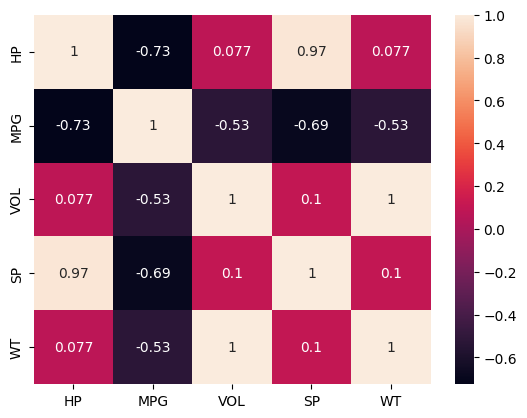

In [17]:
sns.heatmap(data = corr_data, annot = True)

#### there is multi collinearity in the data

### TEST4 : AUTO REGRESSION TEST PASSED - THERE ARE NO TIME FACTORS TO INFLUENCE IN THE IP DATA

## 4. DATA PREPARATION 

In [42]:
### ALL COLUMNS\ FEATURES ARE NUMERIC SO THERE IS NOTHING TO PREPARE
### FEATURE ENGINEERING TECHNIQUES CAN BE APPLIED HERE LATER

In [3]:
X = cars_dataset[["HP","WT","SP","VOL"]]
X

,HP,WT,SP,VOL
0,49,28.762059,104.185353,89
1,55,30.466833,105.461264,92
2,55,30.193597,105.461264,92
3,70,30.632114,113.461264,92
4,53,29.889149,104.461264,92
...,...,...,...,...
76,322,16.132947,169.598513,50
77,238,37.923113,150.576579,115
78,263,15.769625,151.598513,50
79,295,39.423099,167.944460,119


In [4]:
y = cars_dataset["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

## 5. MODEL BUILDING

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.20, shuffle = True)

In [7]:
X_train

,HP,WT,SP,VOL
40,95,37.392524,116.392639,113
13,73,29.378436,111.185353,89
2,55,30.193597,105.461264,92
70,280,15.823060,164.598513,50
35,90,31.911223,115.013085,98
...,...,...,...,...
7,62,15.847758,102.598513,50
31,84,33.234361,112.288996,101
61,120,37.860411,117.668550,116
34,81,32.701644,111.288996,101


In [8]:
linear_model = LinearRegression()

## 6.MODEL TRIANING

In [9]:
linear_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0.19, 0.62, 0.37,-0.42]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['HP','WT','SP','VOL']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,33.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [10]:
linear_model.intercept_   ## all the 4 x values intercept y axis at 30.67 when x=0

np.float64(33.90449465702417)

In [11]:
linear_model.coef_ ### slope values for each x data

array([-0.19473121,  0.61528288,  0.3691893 , -0.41971586])

## 7. MODEL TESTING

In [12]:
y_pred_train = (linear_model.predict(X_train)).round(2)
y_pred_train

array([33.96, 41.46, 42.09, 28.9 , 37.34, 42.4 , 38.3 , 26.34, 18.22,
       24.27, 48.11, 26.21, 48.79, 41.6 , 39.76, 40.92, 34.39, 37.19,
       39.26, 22.76, 36.98, 16.17, 40.59, 24.89, 38.26, 38.03, 25.92,
       36.91, 41.7 , 38.1 , 18.14, 22.78, 33.38, 23.4 , 35.4 , 29.85,
       28.23, 38.72, 33.23, 48.38, 22.03, 42.91, 32.93, 33.36, 12.77,
       42.26, 35.2 , 37.53, 43.17, 41.16, 35.56, 35.93, 23.71, 27.38,
       37.58, 33.94, 35.45, 21.06, 27.51, 48.47, 37.06, 28.59, 36.95,
       20.48])

In [13]:
y_pred_test = (linear_model.predict(X_test)).round(2)
y_pred_test

array([39.71, 47.18, 41.93, 36.99, 35.79, 34.55, 28.77, 28.19, 32.01,
       34.89, 35.93, 38.61, 41.45, 36.19, 39.45, 37.51, 42.16])

## 8. MODEL EVALUATION

In [16]:
error_train = y_train - y_pred_train
error_train

40    1.192727
13    3.192834
2     7.923401
70   -9.221493
35    0.618743
        ...   
7    -1.753446
31    2.371235
61   -3.980868
34    2.581633
69    0.793708
Name: MPG, Length: 64, dtype: float64

In [17]:
cars_dataset["error"] = error_train
cars_dataset

,HP,MPG,VOL,SP,WT,error
0,49,53.700681,89,104.185353,28.762059,10.530681
1,55,50.013401,92,105.461264,30.466833,7.753401
2,55,50.013401,92,105.461264,30.193597,7.923401
3,70,45.696322,92,113.461264,30.632114,3.296322
4,53,50.504232,92,104.461264,29.889149,NaN
...,...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947,14.140000
77,238,19.197888,115,150.576579,37.923113,0.977888
78,263,34.000000,50,151.598513,15.769625,6.620000
79,295,19.833733,119,167.944460,39.423099,7.063733


#### actual evaluation for regression algorithms::::::

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [34]:
mean_absolute_error(y_train,y_pred_train)

3.41128181828125

In [35]:
mean_absolute_error(y_test,y_pred_test)

2.9939203129411767

In [37]:
mean_squared_error(y_train,y_pred_train)

20.30360505507567

In [38]:
mean_squared_error(y_test,y_pred_test)

14.601987751442245

In [40]:
root_mean_squared_error(y_train,y_pred_train)

4.505952180735574

In [41]:
root_mean_squared_error(y_test,y_pred_test)

3.821254735220127

In [43]:
r2_score(y_train,y_pred_train)

0.733438919228702

In [68]:
#r2_score(y_test,y_pred_test)

In [49]:
train_dataf = X_train.copy()

In [51]:
train_dataf["MPG"] = y_train

In [45]:
import statsmodels.formula.api as smf

In [53]:
stats_linear_model = smf.ols(formula="MPG~HP+WT+VOL+SP",data = train_dataf).fit()

In [58]:
print("r2score:", (stats_linear_model.rsquared).round(2), "\nadjusted r2score:",(stats_linear_model.rsquared_adj).round(2))

r2score: 0.73 
adjusted r2score: 0.72


In [69]:
#stats_y_pred_test = (stats_linear_model.predict(X_test)).round(2)
#stats_y_pred_test

In [70]:
#stats_y_pred_train = (stats_linear_model.predict(X_train)).round(2)
#stats_y_pred_train

In [77]:
stats_linear_model1 = smf.ols(formula="MPG~HP",data = train_dataf).fit()

In [85]:
print("r2score:", (stats_linear_model1.rsquared).round(4), "\nadjusted r2score:",(stats_linear_model1.rsquared_adj).round(4))

r2score: 0.4317 
adjusted r2score: 0.4225


In [79]:
stats_linear_model2 = smf.ols(formula="MPG~HP+VOL",data = train_dataf).fit()

In [86]:
print("r2score:", (stats_linear_model2.rsquared).round(4), "\nadjusted r2score:",(stats_linear_model2.rsquared_adj).round(4))

r2score: 0.7211 
adjusted r2score: 0.712


In [81]:
stats_linear_model3 = smf.ols(formula="MPG~HP+VOL+WT",data = train_dataf).fit()

In [87]:
print("r2score:", (stats_linear_model3.rsquared).round(4), "\nadjusted r2score:",(stats_linear_model3.rsquared_adj).round(4))

r2score: 0.7229 
adjusted r2score: 0.7091


In [83]:
stats_linear_model4 = smf.ols(formula="MPG~HP+VOL+WT+SP",data = train_dataf).fit()

In [88]:
print("r2score:", (stats_linear_model4.rsquared).round(4), "\nadjusted r2score:",(stats_linear_model4.rsquared_adj).round(4))

r2score: 0.7335 
adjusted r2score: 0.7154


## lets now perform homoscadisticity test - error values obtained above should follw a pattern 

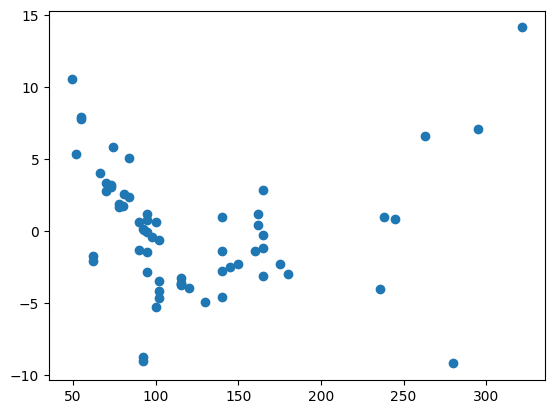

In [18]:
plt.scatter(data = cars_dataset, x="HP", y="error")

<Axes: xlabel='HP', ylabel='error'>

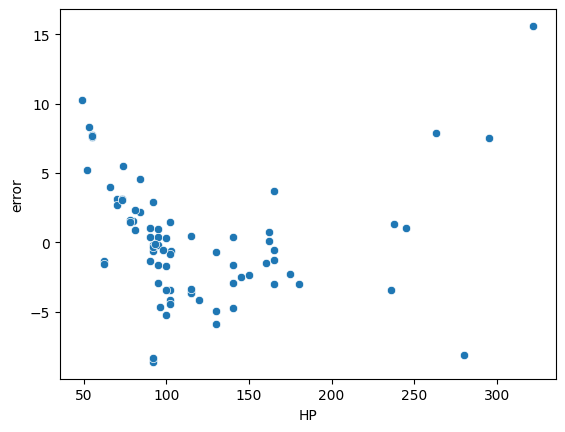

In [68]:
sns.scatterplot(data = cars_dataset, x= "HP", y = "error")

In [71]:
del cars_dataset["error"]

In [72]:
cars_dataset

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


<Axes: xlabel='HP', ylabel='MPG'>

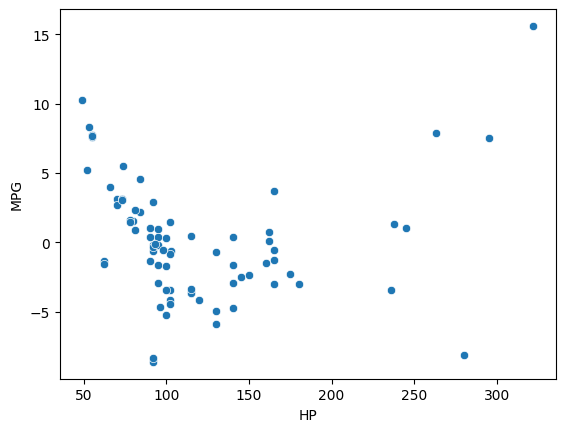

In [73]:
sns.scatterplot(data = cars_dataset, x= "HP", y = error)


<Axes: xlabel='VOL', ylabel='MPG'>

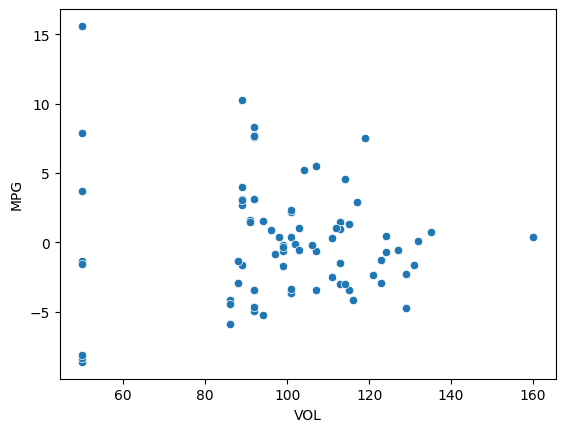

In [74]:
sns.scatterplot(data = cars_dataset, x= "VOL", y = error)

<Axes: xlabel='WT', ylabel='MPG'>

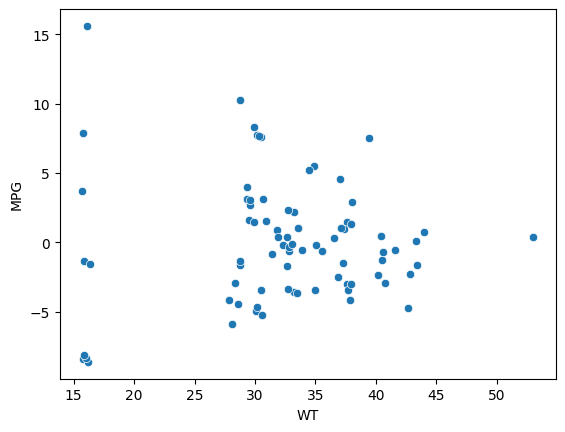

In [75]:
sns.scatterplot(data = cars_dataset, x= "WT", y = error)

### HOMOSCADCTICITY TEST ALSO FAILED - variance in error should reamain constant in both ways in regression test(equal from zero)

### TEST 6 :  ZERO RESIDUAL MEAN TEST

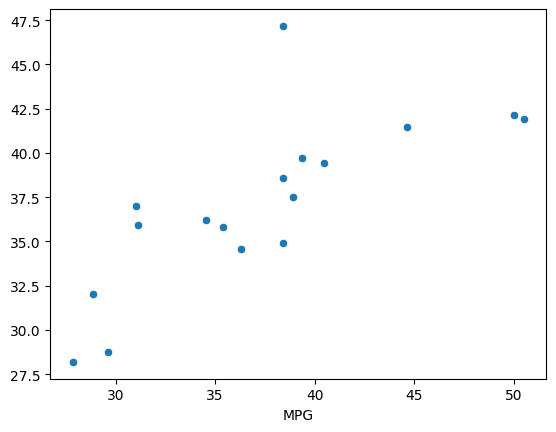

In [39]:

sns.scatterplot(x=y_test,y=y_pred_test)
plt.show()

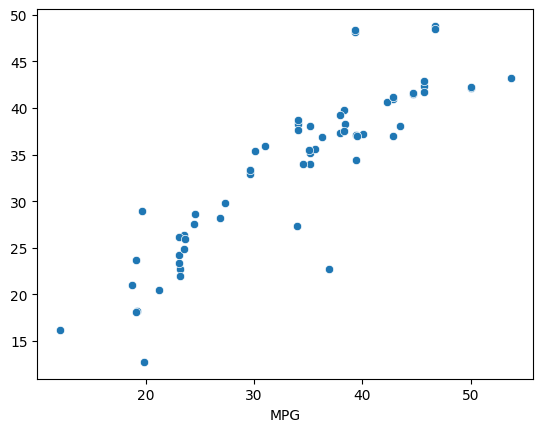

In [38]:
sns.scatterplot(x=y_train,y=y_pred_train)
plt.show()

### THIS TEST ALSO FAILED, BECAUSE THE PLOTS SHOULD BE VERY NEAR TO THE LINE IT IS VERY MUCH SCATTERED

## 9. MODEL DEPLOYEMENT

In [77]:
from pickle import dump

In [83]:
dump(obj = linear_model, file = open(file = "linear_intelligence_file1.pkl", mode = "xb"))

In [84]:
from pickle import load


In [85]:
intel_file = load(file = open( file = "linear_intelligence_file1.pkl", mode = "rb"))
intel_file

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0.21, 0.4 , 0.4 ,-0.34]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['HP','WT','SP','VOL']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.68
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [87]:
intel_file.predict(X)

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21